🔹 🔸 Cell 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

🔹 🔸 Cell 2: Load Clean Data

In [3]:
listings = pd.read_csv('../data/processed/clean_listings.csv')
reviews = pd.read_csv('../data/processed/clean_reviews.csv')

listings.head()

C:\Users\Shree\AppData\Local\Temp\ipykernel_21080\1792769237.py:1: DtypeWarning: Columns (0: host_response_time, 1: district) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('../data/processed/clean_listings.csv')


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


🔹 🔸 Cell 3: Price Distribution

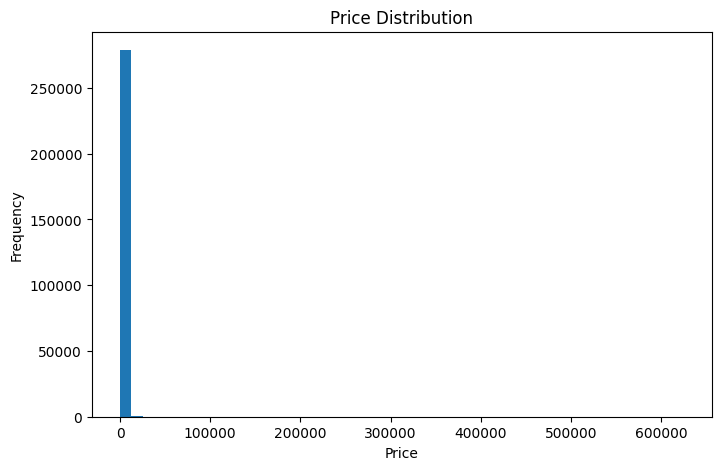

In [4]:
plt.figure(figsize=(8,5))
plt.hist(listings['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

🔹 🔸 Cell 4: Top Expensive Listings

In [5]:
listings.sort_values(by='price', ascending=False)[['name', 'price']].head(10)

,name,price
181027,Temporary rentals for Brazilian Cup.,625216.0
162251,Hotel Boutique Maison Salamanca,499000.0
98808,Habitacion a 40min del centro historico,350000.0
135705,Amazing view and pool in center Bkk,300177.0
218597,Charoenkrung Road House/Office Rent,300000.0
182185,Airport-MRT-ShowShopFood-FullFN,300000.0
44906,Ã¥â¦Â¬Ã¥Â¯â,231047.0
196424,Room in the most exclusive area in Mexico City,206499.0
97609,Ã¥Â¥Â¢Ã¥ÂÅ½Ã§Â§ÂÃ¥Â®Â¶Ã¥ÂºâÃ¥âºÂ­Ã¯Â¼ÅÃ¤...,180124.0
208690,Casa Vertientes,180000.0


🔹 🔸 Cell 5: Listings by Location

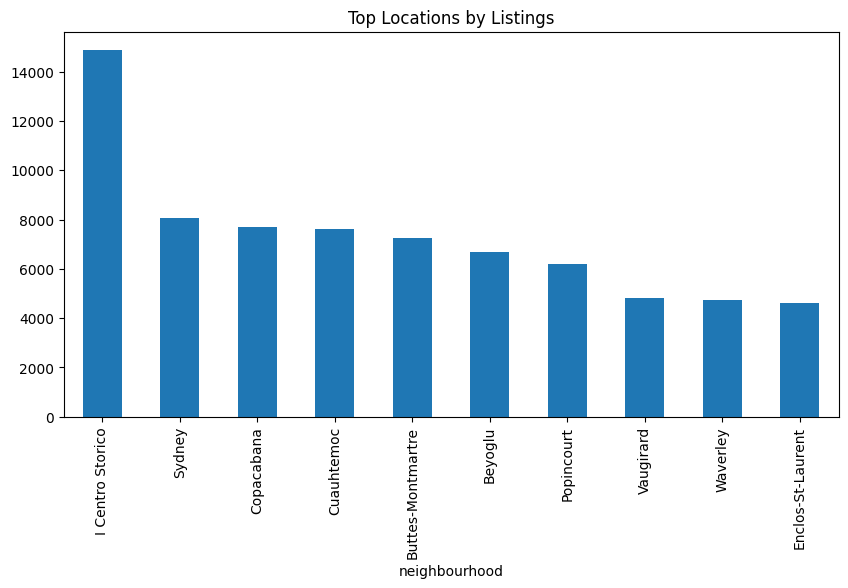

In [6]:
top_locations = listings['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')
plt.title("Top Locations by Listings")
plt.show()

🔹 🔸 Cell 6: Price vs Rating

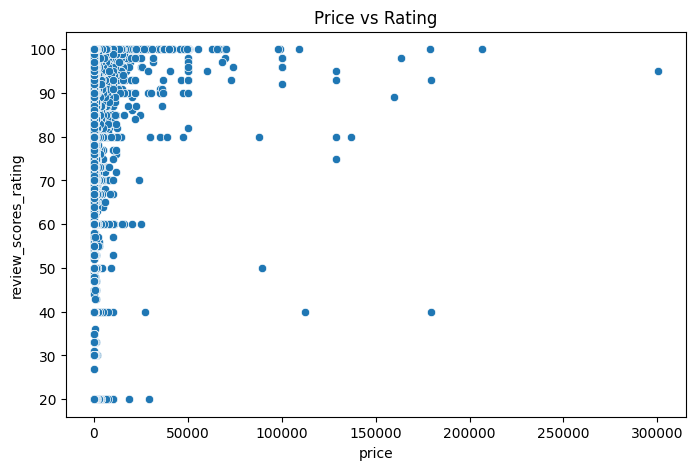

In [7]:
if 'review_scores_rating' in listings.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='price', y='review_scores_rating', data=listings)
    plt.title("Price vs Rating")
    plt.show()

🔹 🔸 Cell 7: Review Trends Over Time

In [9]:
print(reviews.columns)

Index(['listing_id', 'review_id', 'date', 'reviewer_id'], dtype='str')


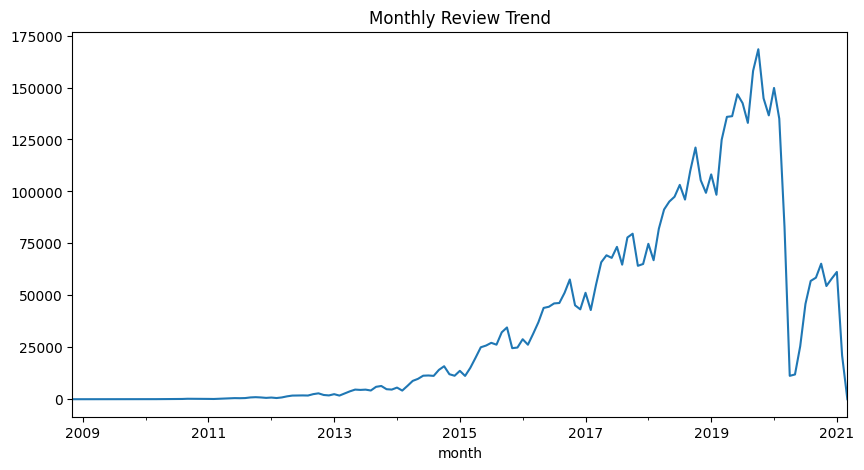

In [11]:
reviews['date'] = pd.to_datetime(reviews['date'])

reviews['month'] = reviews['date'].dt.to_period('M')

trend = reviews.groupby('month').size()

trend.plot(figsize=(10,5))
plt.title("Monthly Review Trend")
plt.show()

Reviews per Listing

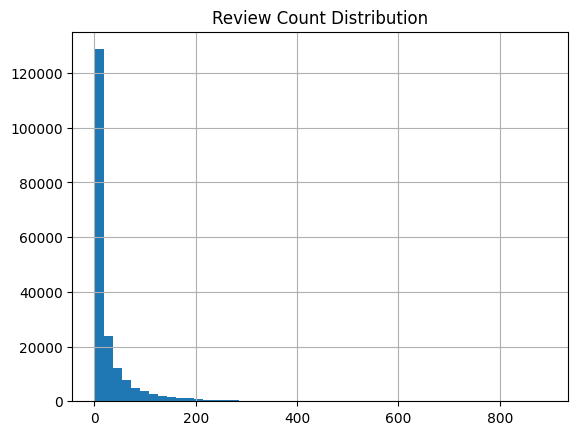

In [ ]:
review_counts = reviews.groupby('listing_id').size()

review_counts.hist(bins=50)
plt.title("Review Count Distribution")
plt.show()

✅ 3. Top Reviewed Listings

🔹 🔸 Cell 9: Average Price by Location

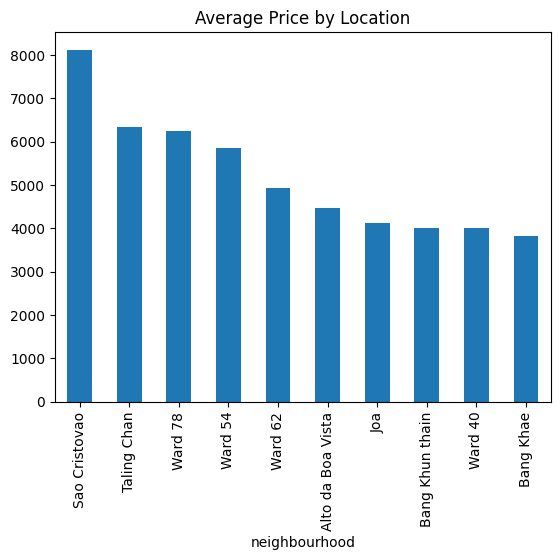

In [ ]:
avg_price = listings.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

avg_price.plot(kind='bar')
plt.title("Average Price by Location")
plt.show()

🔹 🔸 Cell 10: Correlation Heatmap

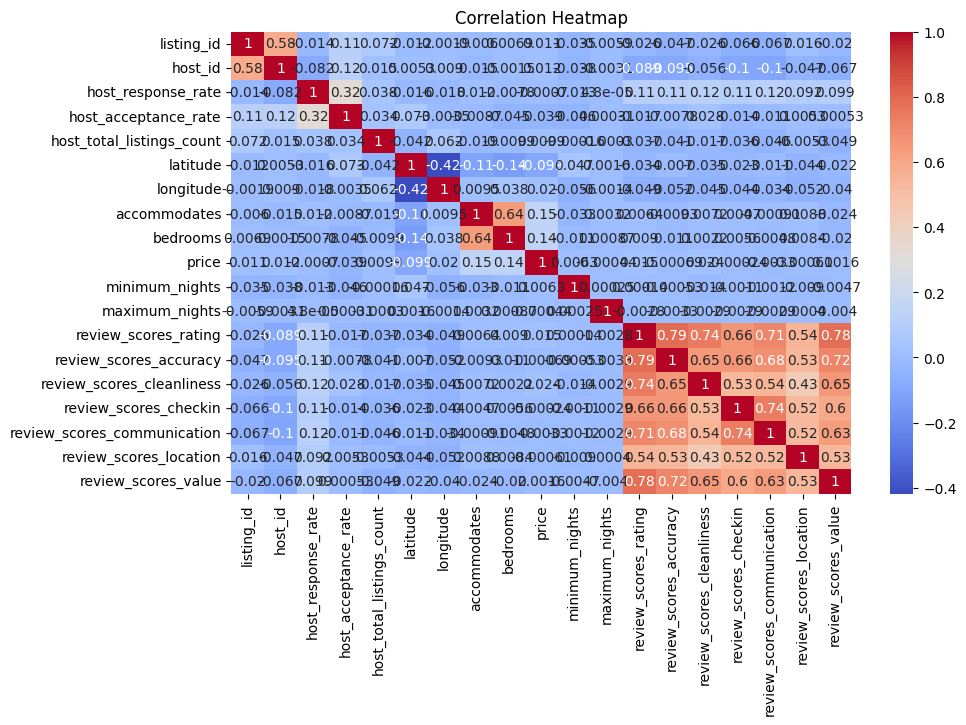

In [20]:
numeric_cols = listings.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Key Insights:

1. Price distribution is highly skewed (few very expensive listings)
2. High price does not always mean high rating
3. Some locations dominate listing counts
4. Positive reviews are more frequent
5. Monthly trends show seasonality in bookings